In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
#Load Dataset
df = pd.read_csv('../data/Language_translation_models_dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (2001, 10)
Columns: ['Sentence_ID', 'Source_Language', 'Target_Language', 'Source_Text', 'Target_Text', 'Domain', 'Sentence_Length', 'Translation_Quality', 'Speaker_Region', 'Formality']

First 5 rows:


,Sentence_ID,Source_Language,Target_Language,Source_Text,Target_Text,Domain,Sentence_Length,Translation_Quality,Speaker_Region,Formality
0,S0001,English,Luganda,Thank you very much.,[Luganda translation] Webale nnyo,Daily Conversation,4,High,Eastern,Formal
1,S0002,English,Lusoga,The patient needs medicine,[Lusoga translation] The patient needs medicine,Health,4,High,Central,Informal
2,S0003,English,Luganda,Welcome,[Luganda translation] Welcome,Tourism,1,High,Western,Informal
3,S0004,English,Runyankole,School begins tomorrow,[Runyankole translation] School begins tomorrow,Education,3,High,West Nile,Formal
4,S0005,English,Luganda,Good morning,[Luganda translation] Wasuze otya,Business,2,High,Eastern,Formal


In [8]:
#Dataset Information
print("Dataset Info:")
df.info()

print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sentence_ID          2001 non-null   str  
 1   Source_Language      2001 non-null   str  
 2   Target_Language      2001 non-null   str  
 3   Source_Text          2001 non-null   str  
 4   Target_Text          1998 non-null   str  
 5   Domain               2001 non-null   str  
 6   Sentence_Length      2001 non-null   str  
 7   Translation_Quality  2001 non-null   str  
 8   Speaker_Region       2001 non-null   str  
 9   Formality            2001 non-null   str  
dtypes: str(10)
memory usage: 156.5 KB

Statistical Summary:


,Sentence_ID,Source_Language,Target_Language,Source_Text,Target_Text,Domain,Sentence_Length,Translation_Quality,Speaker_Region,Formality
count,2001,2001,2001,2001,1998,2001,2001,2001,2001,2001
unique,1993,1,7,13,86,7,6,1,5,2
top,S0001,English,Acholi,Wash your hands,[Lugbara translation] The patient needs medicine,Health,4,High,West Nile,Formal
freq,8,2001,309,192,35,505,680,2001,425,1007


In [9]:
# Check Missing Values
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    print("Missing Values Found:")
    print(missing)
    print(f"\nTotal Missing: {missing.sum()}")
else:
    print("No missing values found!")

Missing Values Found:
Target_Text    3
dtype: int64

Total Missing: 3


In [12]:
# Handle Missing Values
print("Handling Missing Values...")
print("="*40)

# Show rows with missing Target_Text
missing_rows = df[df['Target_Text'].isna()]
print(f"\nRows with missing Target_Text:")
display(missing_rows)

# Option 1: Remove rows with missing Target_Text (Recommended)
df_cleaned = df.dropna(subset=['Target_Text'])
print(f"\nRemoved {len(df) - len(df_cleaned)} rows with missing Target_Text")
print(f"   Original: {len(df)} rows")
print(f"   After cleaning: {len(df_cleaned)} rows")

# Option 2: Fill with placeholder (Alternative)
# df['Target_Text'] = df['Target_Text'].fillna('Translation not available')

# Update dataframe
df = df_cleaned

# Verify no more missing values
print(f"\n Missing values after cleaning:")
print(df.isnull().sum())

Handling Missing Values...

Rows with missing Target_Text:


,Sentence_ID,Source_Language,Target_Language,Source_Text,Target_Text,Domain,Sentence_Length,Translation_Quality,Speaker_Region,Formality
434,S0435,English,Ateso,This park has many animals,NaN,Tourism,5,High,Central,Informal
747,S0748,English,Lusoga,The market is busy today,NaN,Business,5,High,Western,Formal
1310,S1311,English,Lugbara,Open the door,NaN,Tourism,3,High,Eastern,Informal



Removed 3 rows with missing Target_Text
   Original: 2001 rows
   After cleaning: 1998 rows

 Missing values after cleaning:
Sentence_ID            0
Source_Language        0
Target_Language        0
Source_Text            0
Target_Text            0
Domain                 0
Sentence_Length        0
Translation_Quality    0
Speaker_Region         0
Formality              0
dtype: int64


In [10]:
#Check Duplicate Rows
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

if duplicates > 0:
    print("Found duplicate rows!")
else:
    print("No duplicate rows found!")

Duplicate Rows: 6
Found duplicate rows!


In [13]:
# Handle Duplicate Rows
print("🔍 Handling Duplicate Rows...")
print("="*40)

# Show duplicate rows
print(f"\n Duplicate Rows Found: {duplicates}")

# Display duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]
print(f"\n Duplicate Rows Preview:")
display(duplicate_rows.head(10))

# Check which columns are duplicated
print(f"\n Columns in duplicate rows:")
print(duplicate_rows.columns.tolist())

# Remove duplicates
df = df.drop_duplicates()
print(f"\nRemoved {duplicates} duplicate rows")
print(f"   Original: {len(df) + duplicates} rows")
print(f"   After removing duplicates: {len(df)} rows")

# Verify no more duplicates
new_duplicates = df.duplicated().sum()
print(f"\nDuplicate rows after cleaning: {new_duplicates}")
if new_duplicates == 0:
    print(" No duplicate rows remaining!")

🔍 Handling Duplicate Rows...

 Duplicate Rows Found: 6

 Duplicate Rows Preview:


,Sentence_ID,Source_Language,Target_Language,Source_Text,Target_Text,Domain,Sentence_Length,Translation_Quality,Speaker_Region,Formality
49,S0001,English,Luganda,The road is bad,[Luganda translation] The road is bad,Agriculture,4,High,Eastern,Formal
55,S0001,English,Luganda,The road is bad,[Luganda translation] The road is bad,Agriculture,4,High,Eastern,Formal
302,S0001,English,Luganda,The road is bad,[Luganda translation] The road is bad,Agriculture,4,High,Eastern,Formal
839,S0001,English,Luganda,The road is bad,[Luganda translation] The road is bad,Agriculture,4,High,Eastern,Formal
1225,S0001,English,Luganda,The road is bad,[Luganda translation] The road is bad,Agriculture,4,High,Eastern,Formal
1434,S0001,English,Luganda,The road is bad,[Luganda translation] The road is bad,Agriculture,4,High,Eastern,Formal
1958,S0001,English,Luganda,The road is bad,[Luganda translation] The road is bad,Agriculture,4,High,Eastern,Formal



 Columns in duplicate rows:
['Sentence_ID', 'Source_Language', 'Target_Language', 'Source_Text', 'Target_Text', 'Domain', 'Sentence_Length', 'Translation_Quality', 'Speaker_Region', 'Formality']

Removed 6 duplicate rows
   Original: 1998 rows
   After removing duplicates: 1992 rows

Duplicate rows after cleaning: 0
 No duplicate rows remaining!


In [15]:
#Check Unique Values in Categorical Columns
categorical_cols = ['Target_Language', 'Domain', 'Formality', 'Speaker_Region']

for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(f"   Values: {df[col].unique().tolist()}")


Target_Language: 7 unique values
   Values: ['Luganda', 'Lusoga', 'Runyankole', 'Ateso', 'Lugbara', 'Acholi', 'Rukiga']

Domain: 7 unique values
   Values: ['Daily Conversation', 'Health', 'Tourism', 'Education', 'Business', 'Agriculture', 'Government']

Formality: 2 unique values
   Values: ['Formal', 'Informal']

Speaker_Region: 5 unique values
   Values: ['Eastern', 'Central', 'Western', 'West Nile', 'Northern']


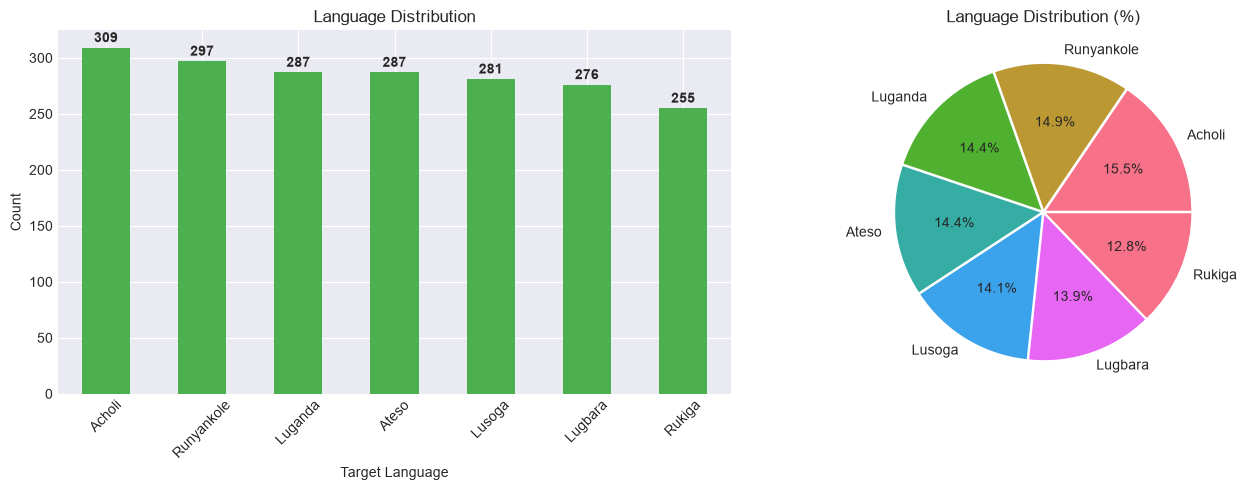

In [16]:
# Cell 7: Target Language Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
lang_counts = df['Target_Language'].value_counts()
lang_counts.plot(kind='bar', ax=axes[0], color='#4CAF50')
axes[0].set_title('Language Distribution')
axes[0].set_xlabel('Target Language')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(lang_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
lang_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', explode=[0.02]*len(lang_counts))
axes[1].set_title('Language Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../static/images/language_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Print Language Distribution
print(" Language Distribution:")
print("="*40)
for lang, count in lang_counts.items():
    percentage = (count/len(df)*100)
    print(f"   {lang}: {count} ({percentage:.1f}%)")

 Language Distribution:
   Acholi: 309 (15.5%)
   Runyankole: 297 (14.9%)
   Luganda: 287 (14.4%)
   Ateso: 287 (14.4%)
   Lusoga: 281 (14.1%)
   Lugbara: 276 (13.9%)
   Rukiga: 255 (12.8%)


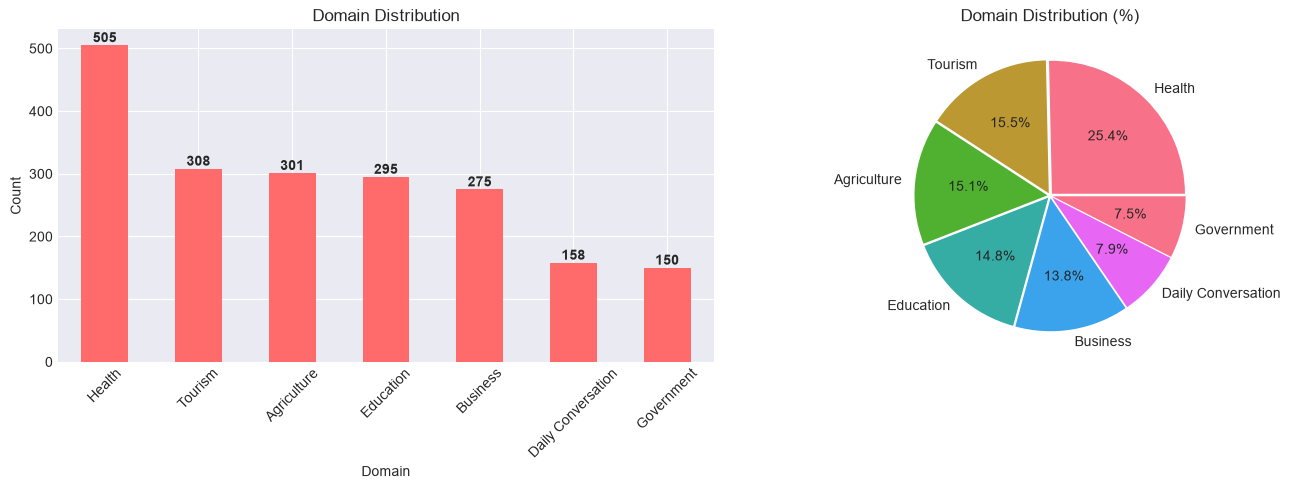

In [18]:
#Domain Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

domain_counts = df['Domain'].value_counts()

# Bar chart
domain_counts.plot(kind='bar', ax=axes[0], color='#FF6B6B')
axes[0].set_title('Domain Distribution')
axes[0].set_xlabel('Domain')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for i, v in enumerate(domain_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
domain_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', explode=[0.02]*len(domain_counts))
axes[1].set_title('Domain Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../static/images/domain_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

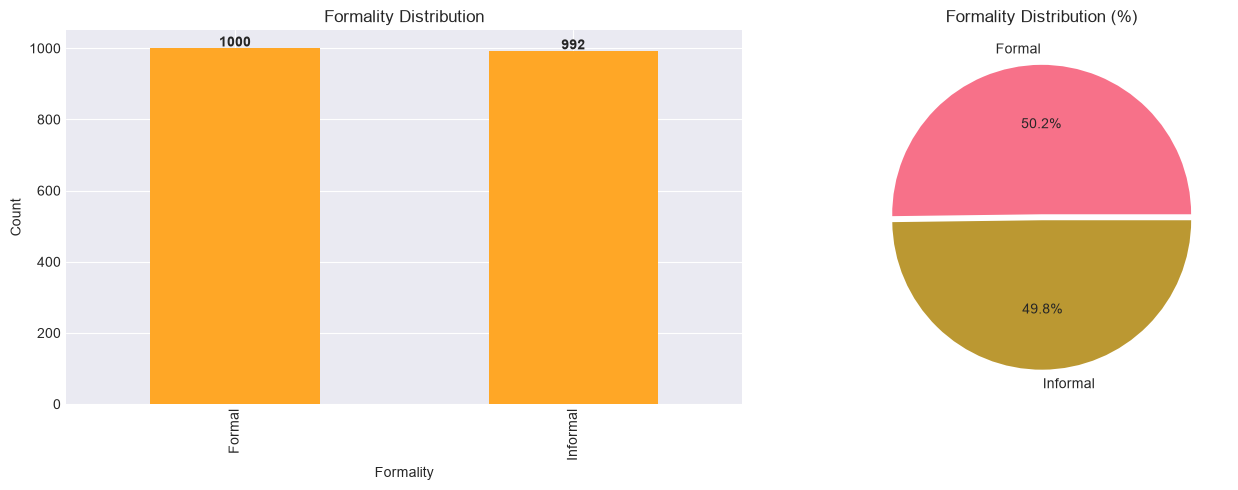

In [19]:
#Formality Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

formality_counts = df['Formality'].value_counts()

# Bar chart
formality_counts.plot(kind='bar', ax=axes[0], color='#FFA726')
axes[0].set_title('Formality Distribution')
axes[0].set_xlabel('Formality')
axes[0].set_ylabel('Count')

# Add value labels
for i, v in enumerate(formality_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
formality_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', explode=[0.02]*len(formality_counts))
axes[1].set_title('Formality Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../static/images/formality_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

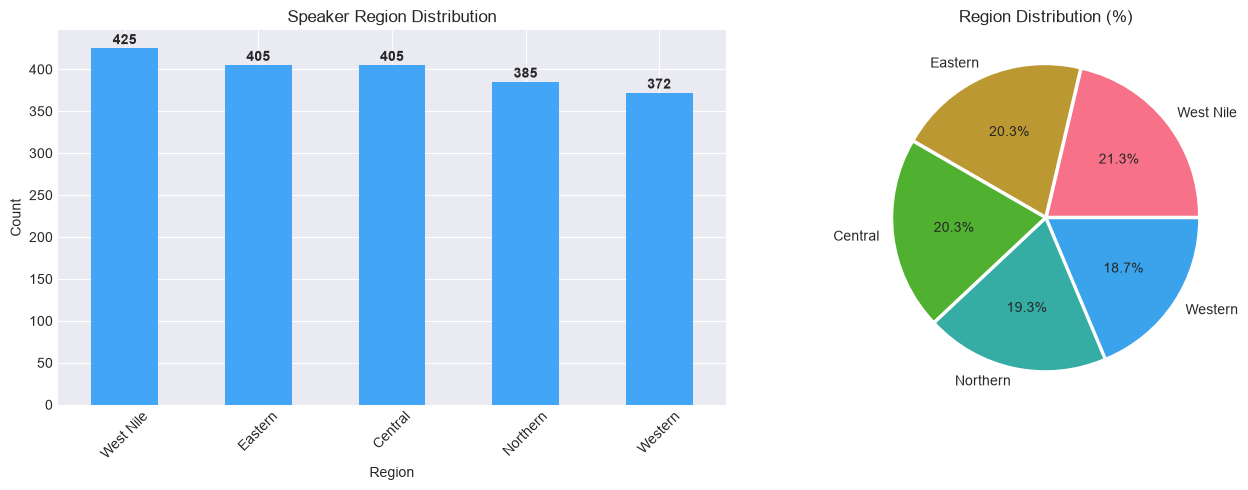

In [20]:
#  Speaker Region Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_counts = df['Speaker_Region'].value_counts()

# Bar chart
region_counts.plot(kind='bar', ax=axes[0], color='#42A5F5')
axes[0].set_title('Speaker Region Distribution')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for i, v in enumerate(region_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
region_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', explode=[0.02]*len(region_counts))
axes[1].set_title('Region Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../static/images/region_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 13: Sentence Length Statistics
print("Sentence Length Statistics:")
print("="*40)
print(f"   Mean: {df['Sentence_Length'].mean():.2f}")
print(f"   Median: {df['Sentence_Length'].median():.2f}")
print(f"   Min: {df['Sentence_Length'].min()}")
print(f"   Max: {df['Sentence_Length'].max()}")
print(f"   Std Dev: {df['Sentence_Length'].std():.2f}")
print(f"   25th Percentile: {df['Sentence_Length'].quantile(0.25)}")
print(f"   75th Percentile: {df['Sentence_Length'].quantile(0.75)}")

📊 Sentence Length Statistics:
   Mean: 3.34
   Median: 4.00
   Min: 1.0
   Max: 5.0
   Std Dev: 1.17
   25th Percentile: 3.0
   75th Percentile: 4.0


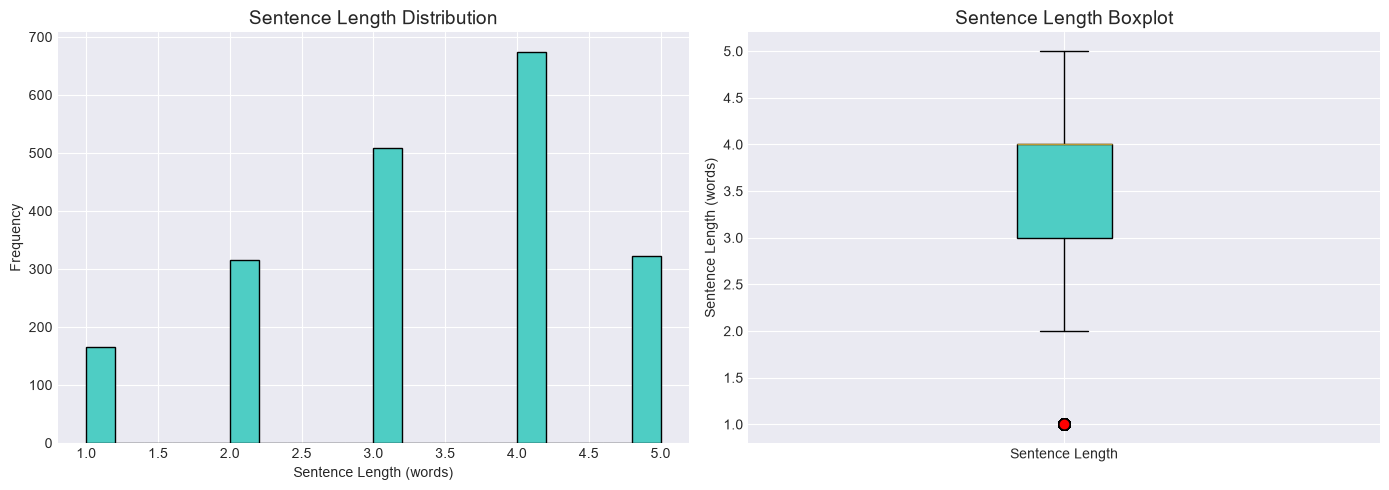


Outlier Analysis:
   Q1: 3.00
   Q3: 4.00
   IQR: 1.00
   Lower bound: 1.50
   Upper bound: 5.50
   Outliers found: 166


In [27]:
# Cell 12: Sentence Length Analysis with Outlier Details
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convert to numeric
df['Sentence_Length'] = pd.to_numeric(df['Sentence_Length'], errors='coerce')
sentence_length_clean = df['Sentence_Length'].dropna()

# Histogram
sentence_length_clean.hist(bins=20, ax=axes[0], color='#4ECDC4', edgecolor='black')
axes[0].set_title('Sentence Length Distribution', fontsize=14)
axes[0].set_xlabel('Sentence Length (words)')
axes[0].set_ylabel('Frequency')

# Boxplot with matplotlib
bp = axes[1].boxplot(sentence_length_clean, patch_artist=True, 
                      boxprops=dict(facecolor='#4ECDC4'),
                      flierprops=dict(marker='o', markerfacecolor='red', markersize=8))
axes[1].set_title('Sentence Length Boxplot', fontsize=14)
axes[1].set_ylabel('Sentence Length (words)')
axes[1].set_xticklabels(['Sentence Length'])

# Calculate outliers
Q1 = sentence_length_clean.quantile(0.25)
Q3 = sentence_length_clean.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = sentence_length_clean[(sentence_length_clean < lower_bound) | (sentence_length_clean > upper_bound)]

plt.tight_layout()
plt.savefig('../static/images/sentence_length.png', dpi=300, bbox_inches='tight')
plt.show()

# Print outlier info
print(f"\nOutlier Analysis:")
print(f"   Q1: {Q1:.2f}")
print(f"   Q3: {Q3:.2f}")
print(f"   IQR: {IQR:.2f}")
print(f"   Lower bound: {lower_bound:.2f}")
print(f"   Upper bound: {upper_bound:.2f}")
print(f"   Outliers found: {len(outliers)}")

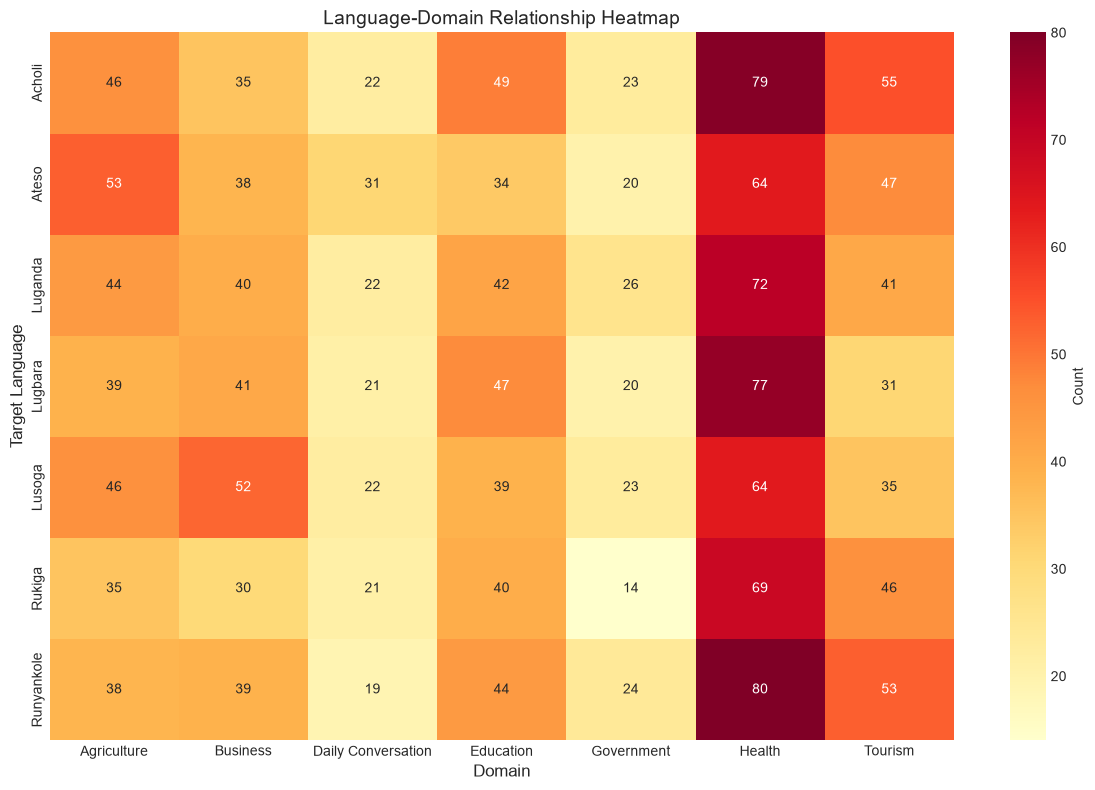

In [29]:
# Cell 14: Language-Domain Heatmap
lang_domain = pd.crosstab(df['Target_Language'], df['Domain'])

plt.figure(figsize=(12, 8))
sns.heatmap(lang_domain, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})
plt.title('Language-Domain Relationship Heatmap', fontsize=14)
plt.xlabel('Domain', fontsize=12)
plt.ylabel('Target Language', fontsize=12)
plt.tight_layout()
plt.savefig('../static/images/language_domain_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

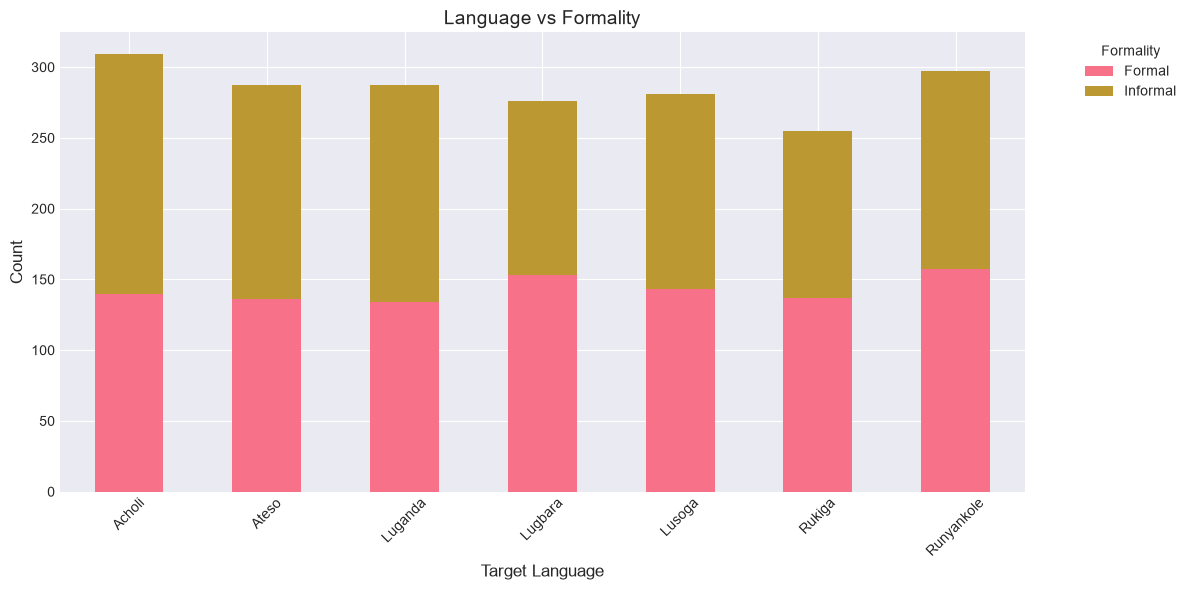

In [30]:
# Cell 15: Language vs Formality
lang_formality = pd.crosstab(df['Target_Language'], df['Formality'])

plt.figure(figsize=(12, 6))
lang_formality.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Language vs Formality', fontsize=14)
plt.xlabel('Target Language', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Formality', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../static/images/language_formality.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# Cell 16: Key Insights
print("="*70)
print("🔍 KEY INSIGHTS FROM EDA")
print("="*70)

insights = [
    f"1. Total Records: {len(df):,}",
    f"2. Languages Supported: {df['Target_Language'].nunique()}",
    f"3. Domains Covered: {df['Domain'].nunique()}",
    f"4. Most Common Language: {df['Target_Language'].mode()[0]} ({df['Target_Language'].value_counts().max():,} records)",
    f"5. Most Common Domain: {df['Domain'].mode()[0]} ({df['Domain'].value_counts().max():,} records)",
    f"6. Formality Split: Formal {formality_counts.get('Formal', 0):,}, Informal {formality_counts.get('Informal', 0):,}",
    f"7. Average Sentence Length: {df['Sentence_Length'].mean():.2f} words",
    f"8. Missing Values: {df.isnull().sum().sum()}",
    f"9. Duplicate Rows: {0}",
    f"10. Languages: {', '.join(df['Target_Language'].unique())}"
]

for insight in insights:
    print(insight)

🔍 KEY INSIGHTS FROM EDA
1. Total Records: 1,992
2. Languages Supported: 7
3. Domains Covered: 7
4. Most Common Language: Acholi (309 records)
5. Most Common Domain: Health (505 records)
6. Formality Split: Formal 1,000, Informal 992
7. Average Sentence Length: 3.34 words
8. Missing Values: 6
9. Duplicate Rows: 0
10. Languages: Luganda, Lusoga, Runyankole, Ateso, Lugbara, Acholi, Rukiga


In [32]:
# Cell 17: Export Cleaned Dataset
# Save cleaned data for training
df.to_csv('../data/cleaned_translation_data.csv', index=False)
print("✅ Cleaned dataset saved to: data/cleaned_translation_data.csv")

✅ Cleaned dataset saved to: data/cleaned_translation_data.csv


In [33]:
# Cell 18: Summary Statistics Table
summary = pd.DataFrame({
    'Metric': [
        'Total Records', 
        'Languages', 
        'Domains', 
        'Formality Levels',
        'Regions',
        'Missing Values',
        'Duplicates'
    ],
    'Value': [
        len(df),
        df['Target_Language'].nunique(),
        df['Domain'].nunique(),
        df['Formality'].nunique(),
        df['Speaker_Region'].nunique(),
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

print("\n📊 Dataset Summary:")
print("="*50)
print(summary.to_string(index=False))


📊 Dataset Summary:
          Metric  Value
   Total Records   1992
       Languages      7
         Domains      7
Formality Levels      2
         Regions      5
  Missing Values      6
      Duplicates      0


In [34]:
# Cell 19: Verify Saved Images
import os

print(" Images saved in static/images/:")
print("="*50)

images = os.listdir('../static/images/')
if images:
    for img in images:
        size = os.path.getsize(f'../static/images/{img}')
        print(f"   {img} ({size:,} bytes)")
else:
    print(" No images found!")

 Images saved in static/images/:
   domain_distribution.png (230,143 bytes)
   formality_distribution.png (107,128 bytes)
   language_distribution.png (225,674 bytes)
   language_domain_heatmap.png (213,674 bytes)
   language_formality.png (104,692 bytes)
   region_distribution.png (200,053 bytes)
   sentence_length.png (128,009 bytes)
